# 🔩 Surface Defect Classification
### Transfer Learning with EfficientNetB0 on the NEU-DET Dataset

This notebook implements an **image classification pipeline** to detect surface defects in steel using **EfficientNetB0** pretrained on ImageNet.

**Pipeline:**
1. Setup & Configuration
2. Data Loading & Exploration
3. Dataset Splitting (Train / Val / Test)
4. Data Augmentation
5. Model Architecture (Transfer Learning)
6. Training
7. Evaluation (Metrics, Confusion Matrix)
8. Misclassification Analysis
9. Save Model & Class Names
10. Inference on New Images


## 1. Setup
### 1.1 Extract Dataset


In [ ]:
!unzip -q archive.zip


### 1.2 Imports


In [ ]:
import os
import json
import math
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 1.3 Global Configuration


In [ ]:
# ─── Hyperparameters ─────────────────────────────────────────────────────────
IMG_SIZE   = 224      # EfficientNetB0 native input resolution
BATCH_SIZE = 16
EPOCHS     = 20
SEED       = 42
AUTOTUNE   = tf.data.AUTOTUNE

# ─── Dataset Paths ───────────────────────────────────────────────────────────
TRAIN_DIR = "NEU-DET/train/images"
VAL_DIR   = "NEU-DET/validation/images"

# ─── Output Paths ────────────────────────────────────────────────────────────
MODEL_SAVE_PATH       = "steel_defect_model.keras"
CLASS_NAMES_SAVE_PATH = "class_names.json"


---
## 2. Data Loading & Exploration
### 2.1 Load Training Dataset


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print(f"Found {NUM_CLASSES} classes: {class_names}")


Found 1440 files belonging to 6 classes.
Found 6 classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


### 2.2 Visualise One Sample Per Class


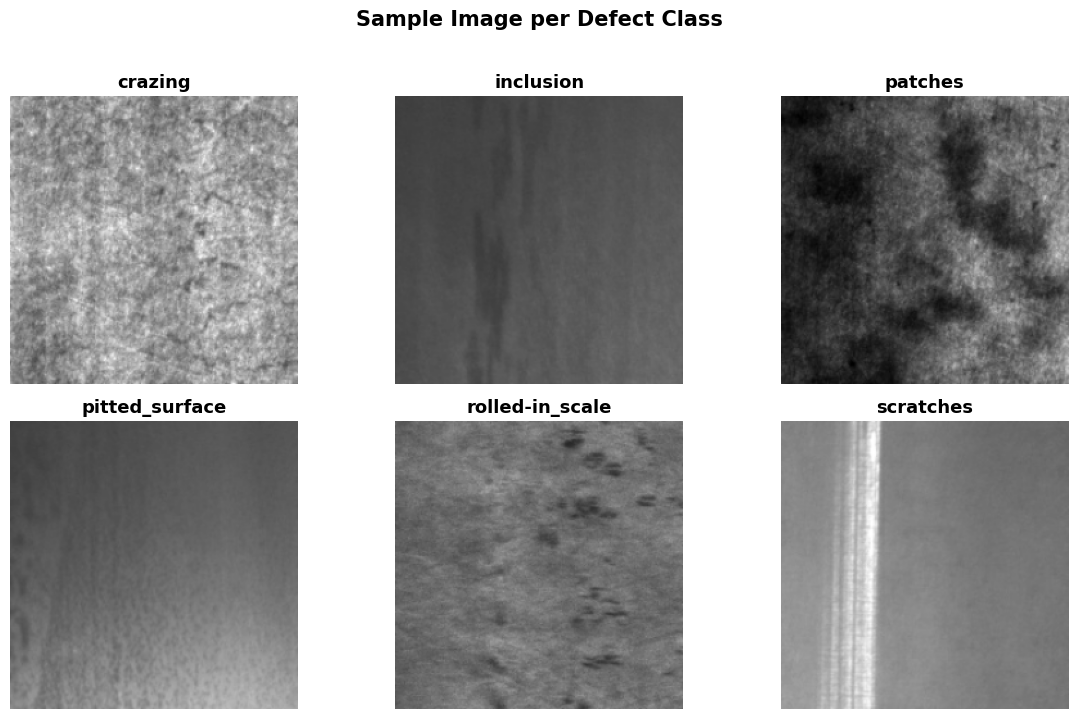

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

shown = {}  # {class_idx: (image, label_name)}

for images, labels in train_ds.unbatch():
    idx = int(np.argmax(labels.numpy()))
    if idx not in shown:
        shown[idx] = (images.numpy().astype('uint8'), class_names[idx])
    if len(shown) == NUM_CLASSES:
        break

for ax, (idx, (img, label)) in zip(axes, sorted(shown.items())):
    ax.imshow(img)
    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.axis("off")

plt.suptitle("Sample Image per Defect Class", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## 3. Dataset Splitting
The official validation directory is split **50 / 50** (stratified) into a validation set used during training, and a held-out test set.


In [ ]:
# ─── Load validation images into memory ─────────────────────────────────────
val_full = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

val_images = tf.concat([img for img, _   in val_full], axis=0)
val_labels = tf.concat([lbl for _,   lbl in val_full], axis=0)

# ─── Stratified 50 / 50 split ────────────────────────────────────────────────
X_val, X_test, y_val, y_test = train_test_split(
    val_images.numpy(),
    val_labels.numpy(),
    test_size=0.5,
    random_state=SEED,
    stratify=np.argmax(val_labels.numpy(), axis=1),
)

print(f"Validation samples : {len(X_val)}")
print(f"Test samples       : {len(X_test)}")

# ─── Build tf.data pipelines ─────────────────────────────────────────────────
def make_dataset(X, y):
    return (
        tf.data.Dataset
        .from_tensor_slices((X, y))
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )

val_ds   = make_dataset(X_val,  y_val)
test_ds  = make_dataset(X_test, y_test)
train_ds = train_ds.shuffle(1000, seed=SEED).prefetch(AUTOTUNE)


Found 360 files belonging to 6 classes.
Validation samples : 180
Test samples       : 180


---
## 4. Data Augmentation
Augmentations are fused into the model graph and applied **only at training time** — zero overhead at inference.


In [ ]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        layers.RandomContrast(0.2),
    ],
    name="data_augmentation",
)


---
## 5. Model Architecture
EfficientNetB0 is used as a **frozen feature extractor**. Only the custom classification head is trained in this phase.

| Component | Details |
|---|---|
| Base model | EfficientNetB0 (ImageNet weights, frozen) |
| Pooling | GlobalAveragePooling2D |
| Dense | 256 units · ReLU · L2 regularisation (0.01) |
| Dropout | 0.6 |
| Output | `NUM_CLASSES` units · Softmax |


In [ ]:
# ─── Frozen base model ───────────────────────────────────────────────────────
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base_model.trainable = False

# ─── Functional API head ─────────────────────────────────────────────────────
inputs  = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")
x       = data_augmentation(inputs)
x       = tf.keras.applications.efficientnet.preprocess_input(x)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D(name="gap")(x)
x       = layers.Dense(
              256,
              activation="relu",
              kernel_regularizer=tf.keras.regularizers.l2(0.01),
              name="dense_head",
          )(x)
x       = layers.Dropout(0.6, name="dropout")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)

model = models.Model(inputs, outputs, name="surface_defect_classifier")
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "surface_defect_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

---
## 6. Training
### 6.1 Compile


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]


### 6.2 Fit


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)


Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 25s 90ms/step - accuracy: 0.7222 - loss: 4.5397 - val_accuracy: 0.7278 - val_loss: 3.5990 - learning_rate: 3.0000e-04
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9306 - loss: 2.8432 - val_accuracy: 0.8944 - val_loss: 2.4392 - learning_rate: 3.0000e-04
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9611 - loss: 2.0007 - val_accuracy: 0.9056 - val_loss: 1.8136 - learning_rate: 3.0000e-04
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9639 - loss: 1.4932 - val_accuracy: 0.8944 - val_loss: 1.4519 - learning_rate: 3.0000e-04
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.9792 - loss: 1.1820 - val_accuracy: 0.9111 - val_loss: 1.1688 - learning_rate: 3.0000e-04
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9771 - loss: 0.9861 - val_accuracy: 0.9111 - val_loss: 1.0204 - learning_rate: 3.0000e-04
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.983

### 6.3 Training Curves


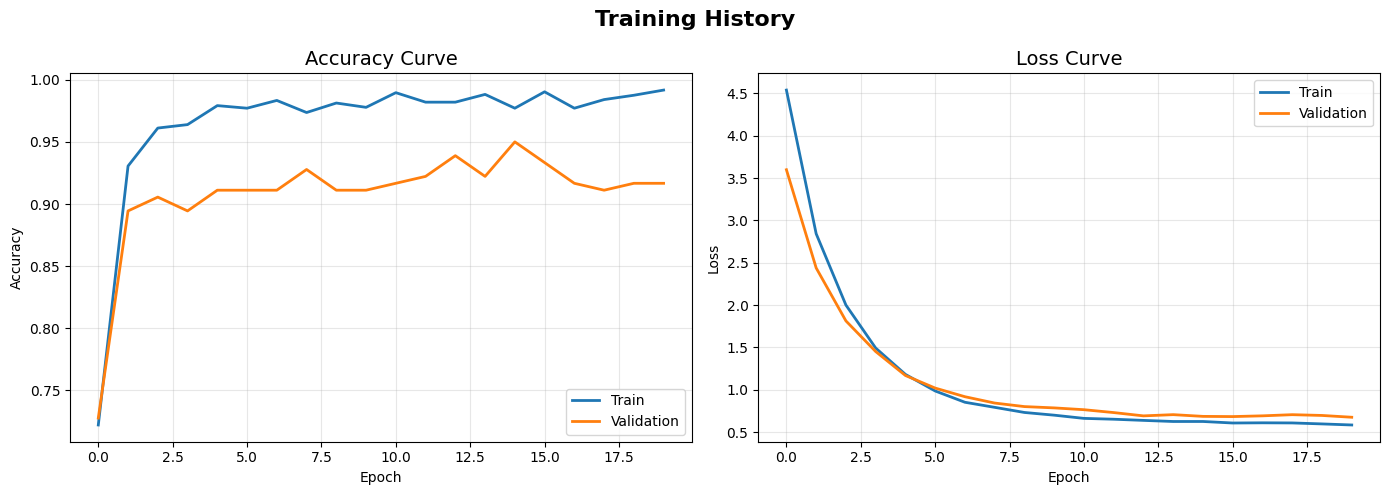

In [ ]:
def plot_history(history):
    """Plot accuracy and loss curves for train/validation."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric in zip(axes, ["accuracy", "loss"]):
        ax.plot(history.history[metric],           label='Train',      linewidth=2)
        ax.plot(history.history[f'val_{metric}'],  label='Validation', linewidth=2)
        ax.set_title(f'{metric.capitalize()} Curve', fontsize=14)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle('Training History', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history)


---
## 7. Evaluation
### 7.1 Helper Functions


In [ ]:
def get_predictions(dataset):
    """Collect ground-truth and model predictions for a full dataset."""
    y_true, y_pred = [], []
    for images_batch, labels_batch in dataset:
        preds = model.predict(images_batch, verbose=0)
        y_true.extend(np.argmax(labels_batch.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """Plot a labelled heatmap confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


### 7.2 Validation Set


Validation Classification Report:

                 precision    recall  f1-score   support

        crazing       0.91      1.00      0.95        30
      inclusion       0.90      0.90      0.90        30
        patches       1.00      1.00      1.00        30
 pitted_surface       1.00      0.77      0.87        30
rolled-in_scale       0.83      1.00      0.91        30
      scratches       0.89      0.83      0.86        30

       accuracy                           0.92       180
      macro avg       0.92      0.92      0.92       180
   weighted avg       0.92      0.92      0.92       180



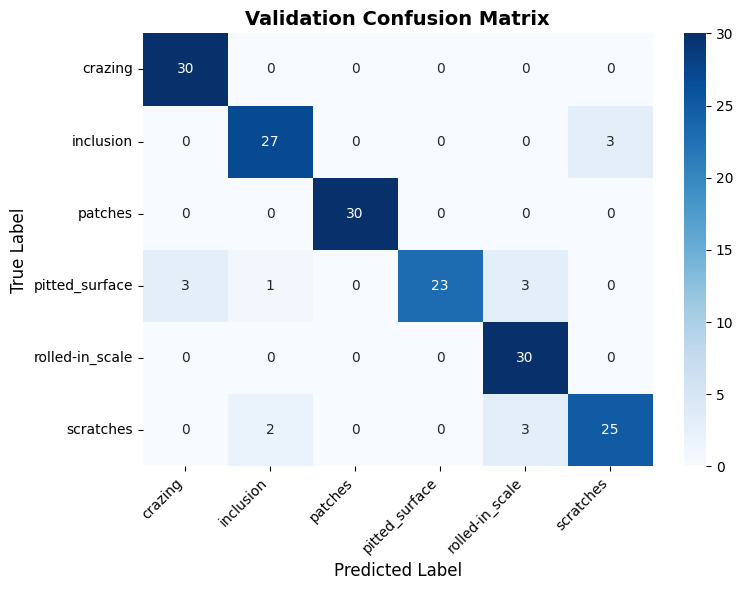

In [ ]:
y_true_val, y_pred_val = get_predictions(val_ds)

print("Validation Classification Report:\n")
print(classification_report(y_true_val, y_pred_val, target_names=class_names))

plot_confusion_matrix(y_true_val, y_pred_val, title="Validation Confusion Matrix")


### 7.3 Test Set


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9278 - loss: 0.6712

Test Accuracy : 0.9278
Test Loss     : 0.6712

Test Classification Report:

                 precision    recall  f1-score   support

        crazing       0.91      1.00      0.95        30
      inclusion       0.93      0.90      0.92        30
        patches       1.00      1.00      1.00        30
 pitted_surface       1.00      0.87      0.93        30
rolled-in_scale       0.86      1.00      0.92        30
      scratches       0.89      0.80      0.84        30

       accuracy                           0.93       180
      macro avg       0.93      0.93      0.93       180
   weighted avg       0.93      0.93      0.93       180



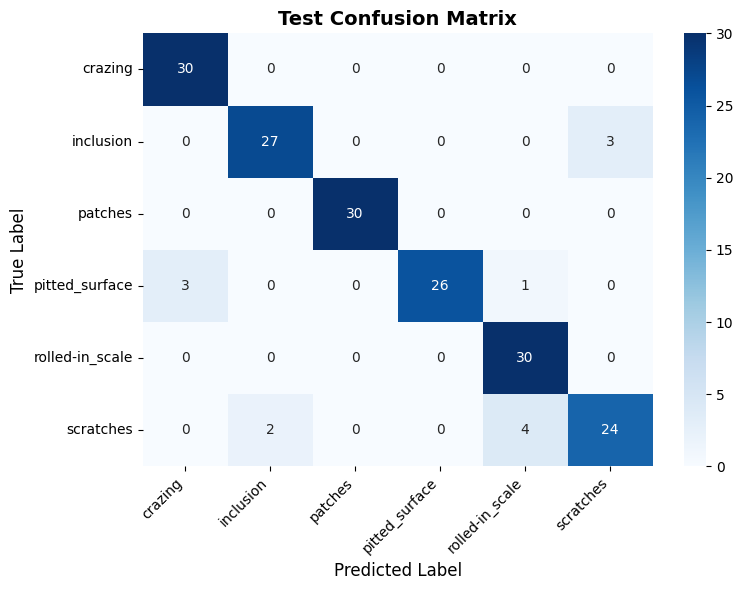

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
print(f"\nTest Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

y_true_test, y_pred_test = get_predictions(test_ds)

print("\nTest Classification Report:\n")
print(classification_report(y_true_test, y_pred_test, target_names=class_names))

plot_confusion_matrix(y_true_test, y_pred_test, title="Test Confusion Matrix")


---
## 8. Misclassification Analysis
Inspect every image the model predicted incorrectly on the test set.


Misclassified: 13 / 180


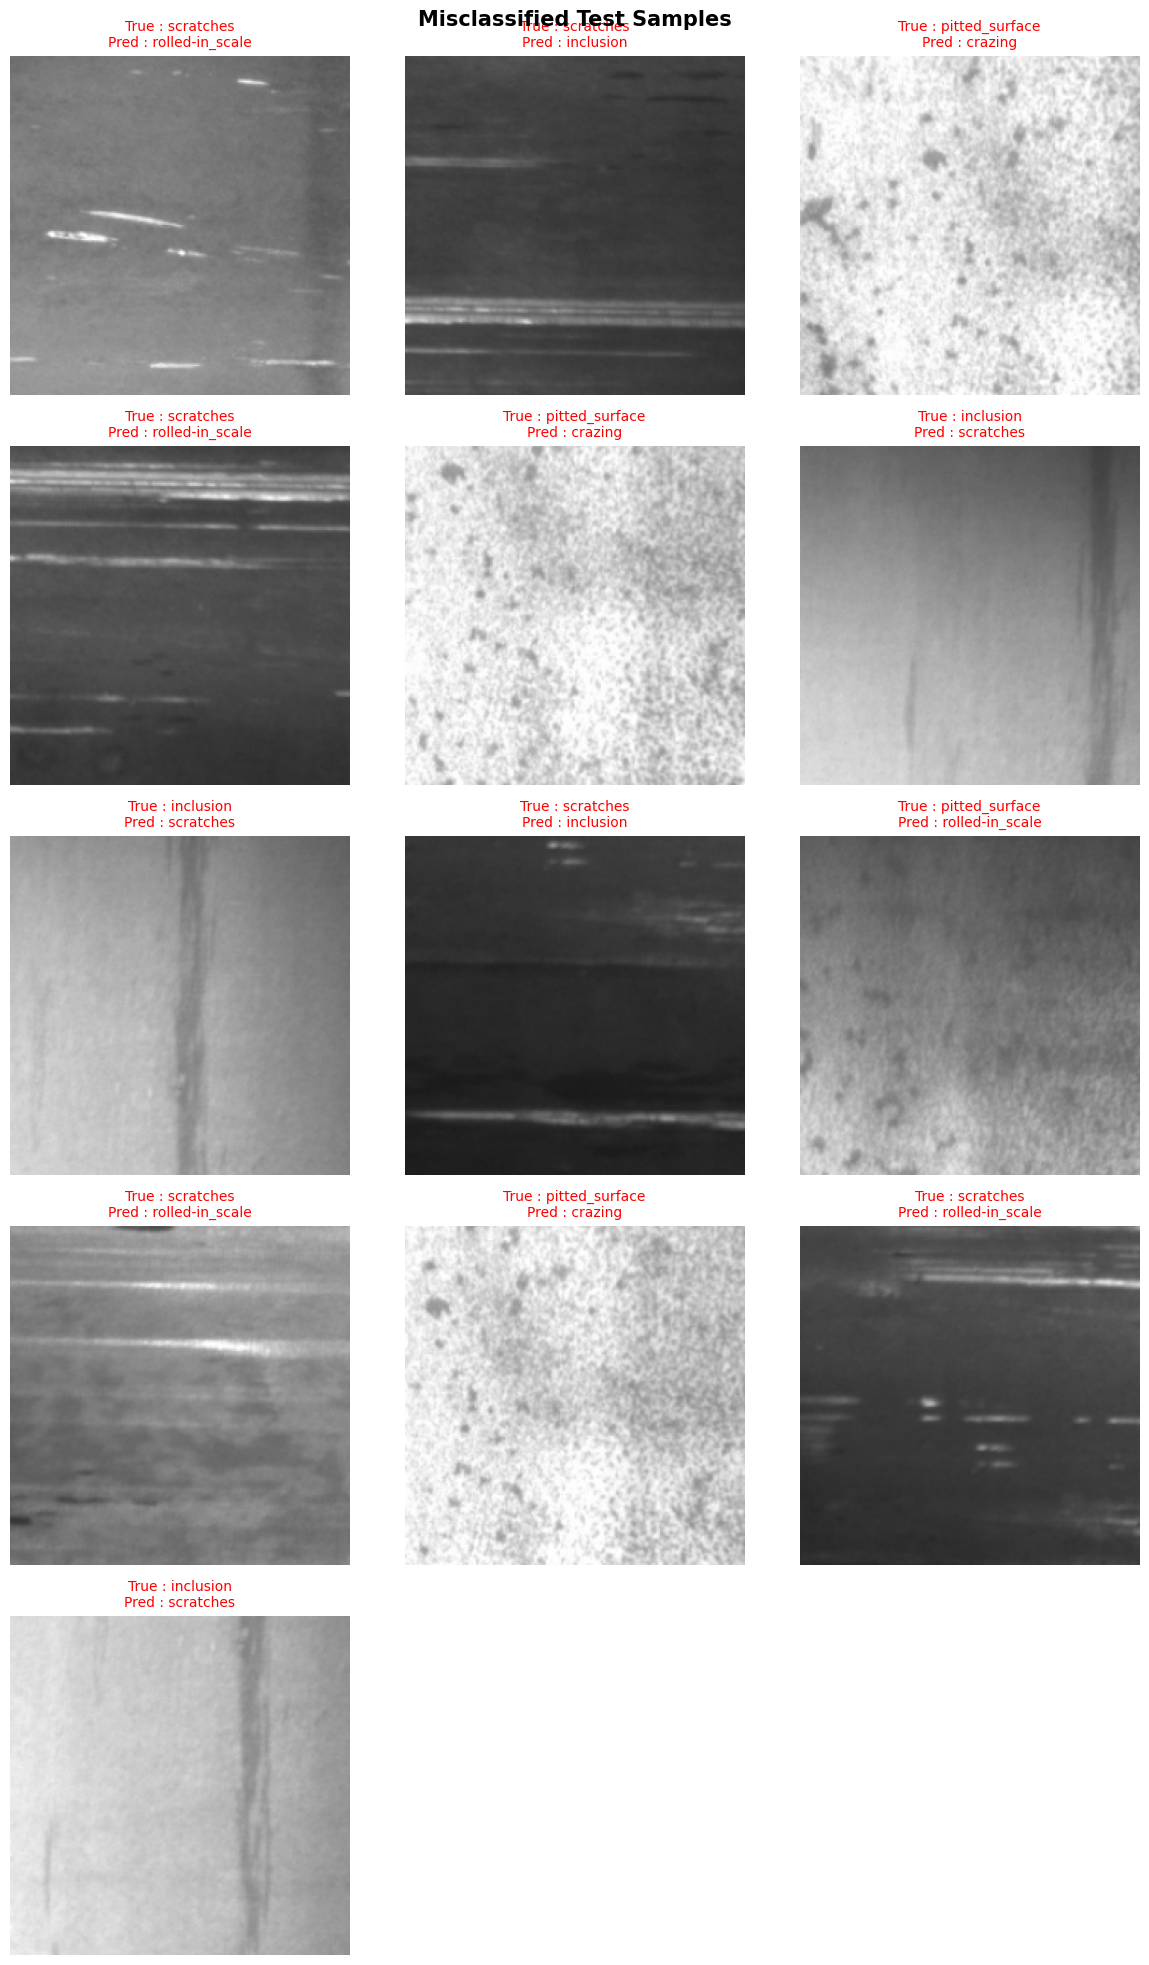

In [ ]:
misclassified = []

for images_batch, labels_batch in test_ds:
    preds = model.predict(images_batch, verbose=0)
    for img, true_lbl, pred_lbl in zip(
        images_batch.numpy(),
        np.argmax(labels_batch.numpy(), axis=1),
        np.argmax(preds, axis=1),
    ):
        if true_lbl != pred_lbl:
            misclassified.append((img, true_lbl, pred_lbl))

print(f"Misclassified: {len(misclassified)} / {len(X_test)}")

if misclassified:
    cols = 3
    rows = math.ceil(len(misclassified) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).flatten()

    for ax, (img, true_lbl, pred_lbl) in zip(axes, misclassified):
        ax.imshow(img.astype('uint8'))
        ax.set_title(
            f'True : {class_names[true_lbl]}\nPred : {class_names[pred_lbl]}',
            fontsize=10, color='red',
        )
        ax.axis('off')

    for ax in axes[len(misclassified):]:
        ax.set_visible(False)

    plt.suptitle('Misclassified Test Samples', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()


---
## 9. Save Model & Class Names


In [ ]:
model.save(MODEL_SAVE_PATH)

with open(CLASS_NAMES_SAVE_PATH, 'w') as f:
    json.dump(class_names, f)

print(f"Model saved       → {MODEL_SAVE_PATH}")
print(f"Class names saved → {CLASS_NAMES_SAVE_PATH}")


Model saved       → steel_defect_model.keras
Class names saved → class_names.json


---
## 11. Export (Google Colab)
Download the model artefacts as a zip archive.


In [ ]:
!zip -qr all_files.zip steel_defect_model.keras class_names.json

from google.colab import files
files.download('all_files.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>